<p> <center><img src="img.jpg" style="height:200px"> </p>

<hr style="border-width:2px;border-color:#AAD">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Features Engineering </h2></center>
<hr style="border-width:2px;border-color:#AAD">

# I - Chargement des données PACA

Cette étape consiste à charger le fichier **"paca_meteo_energie.csv"** contenant les données météorologiques et radiatives régionales pour la région PACA avec une résolution temporelle de **30 minutes**.

Les variables disponibles dans ce jeu de données comprennent notamment:

- **`azimuth`** : azimut solaire (en degrés), indiquant la direction du soleil par rapport au nord (0–360° selon la convention).  
- **`altitude`** : altitude solaire (en degrés), représentant l'élévation du soleil au-dessus de l'horizon (valeurs négatives durant la nuit).  
- **`Temperature`** *(souvent `T2M`)* : température de l'air à 2 mètres du sol (en °C ou en K selon la source ; une vérification des unités est nécessaire).  
- **`GHI`** (*Global Horizontal Irradiance*) : irradiance globale reçue sur un plan horizontal (composantes directe et diffuse) exprimée en Wh/m².  
- **`BHI`** (*Beam Horizontal Irradiance*) : composante directe du rayonnement solaire projetée sur le plan horizontal (Wh/m²).  
- **`DHI`** (*Diffuse Horizontal Irradiance*) : composante diffuse du rayonnement solaire reçue sur un plan horizontal (Wh/m²).  
- **`BNI`** (*Beam Normal Irradiance*) : irradiance directe normale, reçue sur un plan perpendiculaire aux rayons solaires (Wh/m²).  
- **`Vitesse_Vent`** *(souvent `V2M`)* : vitesse du vent mesurée à 2 mètres du sol (m/s).  
- **`Nebulosite`** *(souvent `cloud_AMT`)* : nébulosité ou fraction de couverture nuageuse (exprimée selon les produits en fraction, pourcentage ou indice adimensionnel).  
- **`Humidite`** : humidité de l'air (généralement humidité relative en %, ou humidité spécifique selon la source).  
- **`Clear_sky_GHI`** : irradiance globale horizontale en conditions de ciel clair, utilisée comme référence théorique sans nuages (Wh/m²).  
- **`Clear_sky_BHI`** : composante directe horizontale en conditions de ciel clair (Wh/m²).  
- **`Clear_sky_DHI`** : composante diffuse horizontale en conditions de ciel clair (Wh/m²).  
- **`Clear_sky_BNI`** : irradiance directe normale en conditions de ciel clair (Wh/m²).  
- **`TOA`** (*Top Of Atmosphere*) : rayonnement solaire incident au sommet de l'atmosphère (Wh/m²), utilisé pour le contrôle de cohérence et la normalisation des séries.



Nous commencons par importer les librairies nécessaires pour manipuler nos données :

In [50]:
# Gestion des chemins
from pathlib import Path

# Données et calculs
import pandas as pd
import numpy as np

# Dataviz
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Analyse des variables
from sklearn.feature_selection import VarianceThreshold

# Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Sauvegarder les pipelines
import cloudpickle


On récupère les données collectées aux étapes précédentes :

In [29]:
# Chemin vers le répertoire de données d'entrée
input_path = Path('../data/local_data/input/')

# Chemin vers le répertoire de résultats temporaires
temp_path = Path('../data/local_data/temp/')

# Chemin vers le répertoire de résultats finaux
output_path = Path('../data/local_data/output')

# Chemin du dataset de production
input_datasets = output_path / 'reduced_2020_2025.csv'


In [30]:
# Lecture du fichier de données brutes 2020-2025 et affichage d'informations générales

# Charger le dataset
df = pd.read_csv(
    input_datasets, 
    index_col='datetime_utc', 
    parse_dates=True)

# Afficher le début et la fin du dataset
display(df)

# Afficher les dimensions du dataset
print('Dimensions :', df.shape)


,consommation,target,region_azimuth,region_ghi,region_humidite,region_nebulosite,region_temperature,region_vitesse_vent
datetime_utc,,,,,,,,
2019-12-31 23:00:00+00:00,6123.0,0.0,334.860133,0.0,85.29220,23.86520,3.23070,1.34110
2019-12-31 23:30:00+00:00,5907.0,0.0,353.234530,0.0,83.15510,24.55650,3.38585,1.36150
2020-01-01 00:00:00+00:00,5724.0,0.0,12.560776,0.0,81.01800,25.24780,3.54100,1.38190
2020-01-01 00:30:00+00:00,5749.0,0.0,30.183447,0.0,79.06970,15.23310,3.60800,1.33655
2020-01-01 01:00:00+00:00,5700.0,0.0,44.705668,0.0,77.12140,5.21840,3.67500,1.29120
...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,5838.0,0.0,297.107647,0.0,71.31415,36.40500,1.24320,3.31620
2025-12-30 22:00:00+00:00,5837.0,0.0,306.996098,0.0,70.98610,37.02250,1.09590,3.27060
2025-12-30 22:30:00+00:00,6056.0,0.0,319.404019,0.0,71.32730,36.08765,0.96695,3.15875


Dimensions : (105170, 8)


In [32]:
def remove_region(name):
    if 'region_' in name:
        return name[7:]
    else:
        return name

dico_cols = {}
for col in df.columns:
    dico_cols[col] = remove_region(col)
    
df = df.rename(columns=dico_cols)
display(df.head())


,consommation,target,azimuth,ghi,humidite,nebulosite,temperature,vitesse_vent
datetime_utc,,,,,,,,
2019-12-31 23:00:00+00:00,6123.0,0.0,334.860133,0.0,85.2922,23.8652,3.23070,1.34110
2019-12-31 23:30:00+00:00,5907.0,0.0,353.234530,0.0,83.1551,24.5565,3.38585,1.36150
2020-01-01 00:00:00+00:00,5724.0,0.0,12.560776,0.0,81.0180,25.2478,3.54100,1.38190
2020-01-01 00:30:00+00:00,5749.0,0.0,30.183447,0.0,79.0697,15.2331,3.60800,1.33655
2020-01-01 01:00:00+00:00,5700.0,0.0,44.705668,0.0,77.1214,5.2184,3.67500,1.29120


# II - Encodage temporel

La variabilité de la production photovoltaïque dépend fortement de phénomènes cycliques
(alt. jour/nuit, saisonnalité). Utiliser des variables temporelles discrètes (heure, jour
de l'année) peut introduire des discontinuités artificielles (23h proche de 0h, 31/12 proche
de 01/01). Pour préserver cette continuité, on adopte un [**encodage cyclique sinusoïdal**](https://towardsdatascience.com/cyclical-encoding-an-alternative-to-one-hot-encoding-for-time-series-features-4db46248ebba/).


## A - Encodage de l'heure de la journée et du jour de l'année

$$
\text{sin\_hour}(t) = \sin\left( \frac{2\cdot\pi \cdot \text{hour}(t)}{24} \right), \quad
\text{cos\_hour}(t) = \cos\left( \frac{2\cdot\pi \cdot \text{hour}(t)}{24} \right)
$$
où $\text{hour}(t)$ est une variable continue (heures + minutes).

$$
\text{sin\_day}(t) = \sin\left( \frac{2\cdot\pi \cdot \text{doy}(t)}{N_{\text{jours}}} \right), \quad
\text{cos\_day}(t) = \cos\left( \frac{2\cdot\pi \cdot \text{doy}(t)}{N_{\text{jours}}} \right)
$$

où $N_{\text{jours}} = 365$ ou $366$ (années bissextiles).

Cet encodage respecte la périodicité solaire, évite les ruptures numériques et améliore la généralisation du modèle sur des périodes non vues.

In [33]:
# Encodage cyclique de l'heure
hour = df.index.hour + df.index.minute / 60
df['sin_hour'] = np.sin(2 * np.pi * hour / 24)
df['cos_hour'] = np.cos(2 * np.pi * hour / 24) 

# Encodage cyclique du jour de l'année (avec années bissextiles)
doy = df.index.dayofyear - 1
nb_jour_annee = np.where(df.index.is_leap_year, 366, 365)
df['sin_doy'] = np.sin(2 * np.pi * doy / nb_jour_annee)
df['cos_doy'] = np.cos(2 * np.pi * doy / nb_jour_annee)

# Afficher le début et la fin du dataset
display(df)

# Afficher les dimensions du dataset
print('Dimensions :', df.shape)


,consommation,target,azimuth,ghi,humidite,nebulosite,temperature,vitesse_vent,sin_hour,cos_hour,sin_doy,cos_doy
datetime_utc,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,6123.0,0.0,334.860133,0.0,85.29220,23.86520,3.23070,1.34110,-0.258819,0.965926,-0.017213,0.999852
2019-12-31 23:30:00+00:00,5907.0,0.0,353.234530,0.0,83.15510,24.55650,3.38585,1.36150,-0.130526,0.991445,-0.017213,0.999852
2020-01-01 00:00:00+00:00,5724.0,0.0,12.560776,0.0,81.01800,25.24780,3.54100,1.38190,0.000000,1.000000,0.000000,1.000000
2020-01-01 00:30:00+00:00,5749.0,0.0,30.183447,0.0,79.06970,15.23310,3.60800,1.33655,0.130526,0.991445,0.000000,1.000000
2020-01-01 01:00:00+00:00,5700.0,0.0,44.705668,0.0,77.12140,5.21840,3.67500,1.29120,0.258819,0.965926,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,5838.0,0.0,297.107647,0.0,71.31415,36.40500,1.24320,3.31620,-0.608761,0.793353,-0.034422,0.999407
2025-12-30 22:00:00+00:00,5837.0,0.0,306.996098,0.0,70.98610,37.02250,1.09590,3.27060,-0.500000,0.866025,-0.034422,0.999407
2025-12-30 22:30:00+00:00,6056.0,0.0,319.404019,0.0,71.32730,36.08765,0.96695,3.15875,-0.382683,0.923880,-0.034422,0.999407


Dimensions : (105170, 12)


## B - Visualisation de l'encodage cyclique

La projection sinus/cosinus permet de représenter la cyclicité temporelle sur le cercle unité, en préservant la continuité aux frontières des cycles journaliers et annuels.

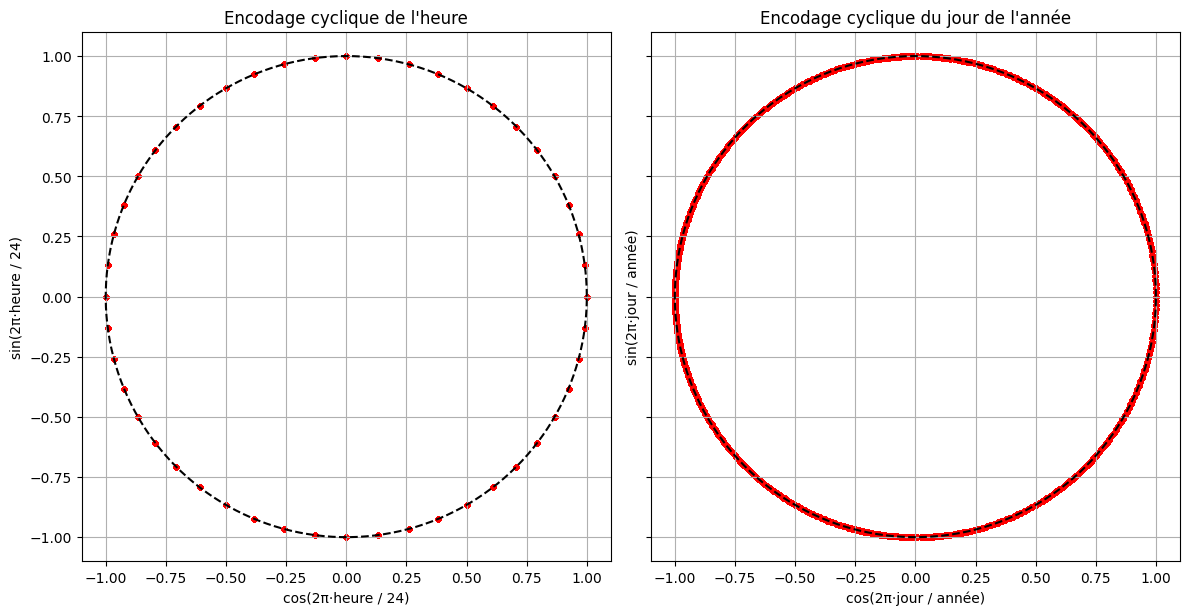

In [34]:
theta = np.linspace(0, 2*np.pi, 360)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# --- Subplot 1 : Encodage cyclique de l'heure ---
ax = axes[0]
ax.scatter(df['cos_hour'], df['sin_hour'], alpha=0.5, s=10, c='red')
ax.plot(np.cos(theta), np.sin(theta), 'k--')  # cercle unité
ax.set_xlabel("cos(2π·heure / 24)")
ax.set_ylabel("sin(2π·heure / 24)")
ax.set_title("Encodage cyclique de l'heure")
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

# --- Subplot 2 : Encodage cyclique du jour de l'année ---
ax = axes[1]
ax.scatter(df['cos_doy'], df['sin_doy'], alpha=0.5, s=10, c='red')
ax.plot(np.cos(theta), np.sin(theta), 'k--')  # cercle unité
ax.set_xlabel("cos(2π·jour / année)")
ax.set_ylabel("sin(2π·jour / année)")
ax.set_title("Encodage cyclique du jour de l'année")
ax.grid(True)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()
    

Les points rouges sont répartis sur le cercle unité, illustrant le caractère cyclique des variables temporelles : les heures proches de minuit (23 h et 0 h) ainsi que les jours situés aux extrémités de l'année (31 décembre et 1er janvier) restent voisins dans l'espace encodé, contrairement à un encodage linéaire.


## C - Continuité de l'encodage cyclique

Les composantes sinus et cosinus varient de manière continue au cours de la journée.

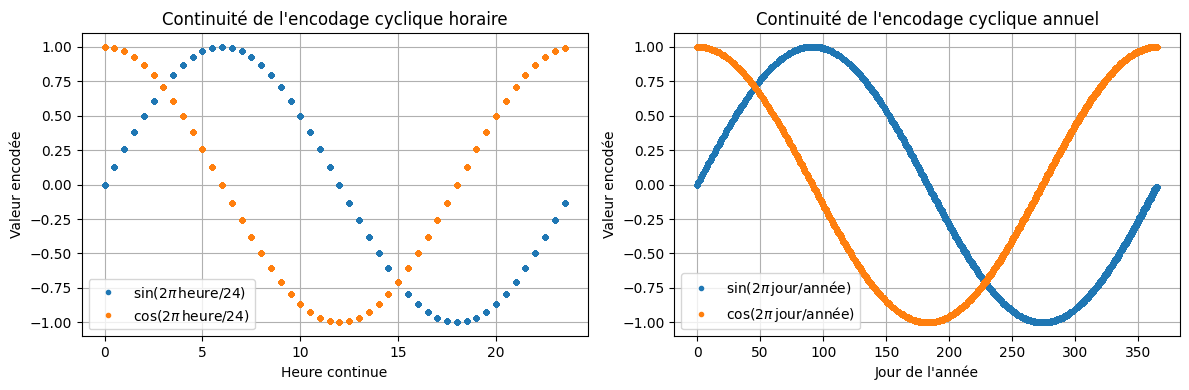

In [35]:
# Encodage cyclique de l'heure (continu, heure + minutes)
hour = df.index.hour + df.index.minute / 60
doy = df.index.dayofyear - 1

plt.figure(figsize=(12, 4))

# --- Plot 1 : Encodage cyclique de l'heure ---
plt.subplot(1, 2, 1)
plt.plot(hour, df['sin_hour'], '.', label=r'$\sin(2\pi\,\mathrm{heure}/24)$')
plt.plot(hour, df['cos_hour'], '.', label=r'$\cos(2\pi\,\mathrm{heure}/24)$')
plt.xlabel("Heure continue")
plt.ylabel("Valeur encodée")
plt.title("Continuité de l'encodage cyclique horaire")
plt.legend()
plt.grid(True)

# --- Plot 2 : Encodage cyclique du jour de l'année ---
plt.subplot(1, 2, 2)
plt.plot(doy, df['sin_doy'], '.', label=r'$\sin(2\pi\,\mathrm{jour}/\mathrm{année})$')
plt.plot(doy, df['cos_doy'], '.', label=r'$\cos(2\pi\,\mathrm{jour}/\mathrm{année})$')
plt.xlabel("Jour de l'année")
plt.ylabel("Valeur encodée")
plt.title("Continuité de l'encodage cyclique annuel")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## D - Continuité autour de minuit et du changement d'année

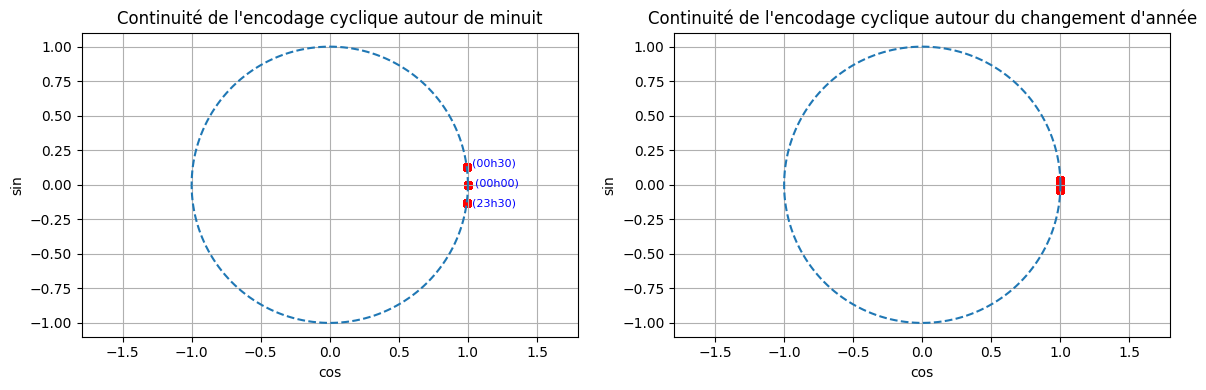

In [36]:
# Encodage cyclique de l'heure (continu, heure + minutes)
hour = df.index.hour + df.index.minute / 60
doy = df.index.dayofyear - 1
year_len = np.where(df.index.is_leap_year, 366, 365)
    
mask_hour = (hour < 1) | (hour > 23)
mask_day  = (doy < 3) | (doy > (year_len - 3))

theta = np.linspace(0, 2*np.pi, 360)

plt.figure(figsize=(12, 4))

# --- Subplot 1 : Continuité autour de minuit ---
plt.subplot(1, 2, 1)
plt.scatter(df.loc[mask_hour, 'cos_hour'],
            df.loc[mask_hour, 'sin_hour'],
            color='red', s=30)

plt.plot(np.cos(theta), np.sin(theta), linestyle='--')
plt.axis('equal')
plt.xlabel("cos")
plt.ylabel("sin")
plt.title("Continuité de l'encodage cyclique autour de minuit")
plt.grid(True)

plt.text(1.05, -0.01, f"(00h00)", fontsize=8, color='blue')
plt.text(1.03, 0.13, f"(00h30)", fontsize=8, color='blue')
plt.text(1.03, -0.16, f"(23h30)", fontsize=8, color='blue')

# --- Subplot 2 : Continuité autour du changement d'année ---
plt.subplot(1, 2, 2)
plt.scatter(df.loc[mask_day, 'cos_doy'],
            df.loc[mask_day, 'sin_doy'],
            color='red', s=30)

plt.plot(np.cos(theta), np.sin(theta), linestyle='--')
plt.axis('equal')
plt.xlabel("cos")
plt.ylabel("sin")
plt.title("Continuité de l'encodage cyclique autour du changement d'année")
plt.grid(True)

plt.tight_layout()
plt.show()

L'utilisation d'un encodage cyclique basé sur les fonctions sinus et cosinus permet de préserver la continuité temporelle de l'heure, notamment autour de la transition minuit, contrairement à un encodage linéaire classique.


# III - Ajout de nouvelles variables explicatives

Aux étapes précédentes, nous avons ajouté notre variable cible, retiré des variables peu significatives et ajouté d'autres, concernant l'**encodage cyclique de la date** (`sin_hour`, `cos_hour`, `sin_doy`, `cos_doy`) et le calcul de la **variable cible** (`target`) à partir de la variable `tch_solaire` aux instants t+1 et t.

Nous avons maintenant besoin de variables donnant une mémoire à notre jeu de données. On va chercher quelques variables particulièrement significative pour la production d'énergie photovoltaïque et introduire de nouvelles variables dérivées de celles ci.

On souhaite réaliser des prédictions à 30 minutes : on s'intéresse particulièrement aux évolutions récentes des variables, dans les heures précédentes (par exemple 2h ou 4h).


In [37]:
# Nombre de pas de temps correspondant aux fenêtres
window_2h = 4   # 2 heures = 4 pas de 30 minutes
window_4h = 8   # 4 heures = 8 pas de 30 minutes

In [38]:
def add_derivate_var(dataset, var, stats=False) :
    X = dataset.copy()
    
    # Lags
    X[var+'_lag_1'] = X[var].shift(1)
    X[var+'_lag_2'] = X[var].shift(2)
    
    # Variation
    X['d'+var+'_dt'] = X[var].diff()

    # Lags de la variation
    X['d'+var+'_lag_1'] = X['d'+var+'_dt'].shift(1)
    X['d'+var+'_lag_2'] = X['d'+var+'_dt'].shift(2)

    if stats :
        # Moyennes glissantes
        X[var+'_mean_2h'] = X[var].rolling(window=window_2h).mean()
        X[var+'_mean_4h'] = X[var].rolling(window=window_4h).mean()

        # Ecarts-type glissants
        X[var+'_std_2h'] = X[var].rolling(window=window_2h).std()
        X[var+'_std_4h'] = X[var].rolling(window=window_4h).std()
    
    return X

## A - Irradiance solaire

**BNI – Beam (Direct) Normal Irradiance**  
Le $BNI$ correspond au rayonnement solaire direct mesuré sur un plan perpendiculaire aux rayons du soleil.  
Sur un plan horizontal, sa contribution s'écrit :
$$
BHI = BNI \cdot \cos(\theta_z)
$$
où $\theta_z = \dfrac{\pi}{2} - \alpha$ est l'angle zénithal solaire et $\alpha$ l'**altitude solaire**, définie comme l'angle entre le soleil et l'horizon.  
Le $BNI$ dépend donc fortement de la position instantanée du soleil et suppose une orientation optimale du capteur. Or, les panneaux photovoltaïques fixes ne sont pas toujours perpendiculaires aux rayons solaires et ne suivent généralement pas le soleil.

**GHI – Global Horizontal Irradiance**  
Le $GHI$ représente le rayonnement solaire total reçu sur un plan horizontal et s'exprime par :
$$
GHI = BHI + DHI = BNI \cdot \cos(\theta_z) + DHI
$$
où $DHI$ est l'irradiance diffuse horizontale.  
Le $GHI$ intègre ainsi les composantes directe et diffuse du rayonnement et décrit plus fidèlement l'irradiation réellement reçue par les panneaux photovoltaïques standards.

**Choix méthodologique**  
Dans notre projet, nous adoptons le **GHI** comme variable d'entrée principale, car il permet une analyse plus représentative et plus robuste de la variabilité de la production solaire à partir de données ouvertes.

On considère donc les variations temporelles de l'irradiance solaire :

$$
\Delta GHI(t) = GHI(t) - GHI(t-\Delta t)
$$
avec $\Delta t = 30$ minutes.


In [39]:
df = add_derivate_var(df, 'ghi', stats=True)

# Afficher le début et la fin du dataset
display(df)

# Afficher les dimensions du dataset
print('Dimensions :', df.shape)


,consommation,target,azimuth,ghi,humidite,nebulosite,temperature,vitesse_vent,sin_hour,cos_hour,...,cos_doy,ghi_lag_1,ghi_lag_2,dghi_dt,dghi_lag_1,dghi_lag_2,ghi_mean_2h,ghi_mean_4h,ghi_std_2h,ghi_std_4h
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,6123.0,0.0,334.860133,0.0,85.29220,23.86520,3.23070,1.34110,-0.258819,0.965926,...,0.999852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 23:30:00+00:00,5907.0,0.0,353.234530,0.0,83.15510,24.55650,3.38585,1.36150,-0.130526,0.991445,...,0.999852,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:00:00+00:00,5724.0,0.0,12.560776,0.0,81.01800,25.24780,3.54100,1.38190,0.000000,1.000000,...,1.000000,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:30:00+00:00,5749.0,0.0,30.183447,0.0,79.06970,15.23310,3.60800,1.33655,0.130526,0.991445,...,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN
2020-01-01 01:00:00+00:00,5700.0,0.0,44.705668,0.0,77.12140,5.21840,3.67500,1.29120,0.258819,0.965926,...,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,5838.0,0.0,297.107647,0.0,71.31415,36.40500,1.24320,3.31620,-0.608761,0.793353,...,0.999407,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-30 22:00:00+00:00,5837.0,0.0,306.996098,0.0,70.98610,37.02250,1.09590,3.27060,-0.500000,0.866025,...,0.999407,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-30 22:30:00+00:00,6056.0,0.0,319.404019,0.0,71.32730,36.08765,0.96695,3.15875,-0.382683,0.923880,...,0.999407,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Dimensions : (105170, 21)


## B - Nébulosité

Les rampes de production photovoltaïque sont principalement déclenchées par des variations rapides de l'irradiance solaire, généralement associées aux passages nuageux.

On considère donc les variations temporelles de la nébulosité :

$$
\Delta \text{Nebulosite}(t) =
\text{Nebulosite}(t) -
\text{Nebulosite}(t-\Delta t)
$$
avec $\Delta t = 30$ minutes.

Ces variables capturent directement les transitions nuageuses responsables des rampes de production photovoltaïque.


In [40]:
df = add_derivate_var(df, 'nebulosite')

# Afficher le début et la fin du dataset
display(df)

# Afficher les dimensions du dataset
print('Dimensions :', df.shape)


,consommation,target,azimuth,ghi,humidite,nebulosite,temperature,vitesse_vent,sin_hour,cos_hour,...,dghi_lag_2,ghi_mean_2h,ghi_mean_4h,ghi_std_2h,ghi_std_4h,nebulosite_lag_1,nebulosite_lag_2,dnebulosite_dt,dnebulosite_lag_1,dnebulosite_lag_2
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,6123.0,0.0,334.860133,0.0,85.29220,23.86520,3.23070,1.34110,-0.258819,0.965926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 23:30:00+00:00,5907.0,0.0,353.234530,0.0,83.15510,24.55650,3.38585,1.36150,-0.130526,0.991445,...,NaN,NaN,NaN,NaN,NaN,23.86520,NaN,0.69130,NaN,NaN
2020-01-01 00:00:00+00:00,5724.0,0.0,12.560776,0.0,81.01800,25.24780,3.54100,1.38190,0.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,24.55650,23.86520,0.69130,0.69130,NaN
2020-01-01 00:30:00+00:00,5749.0,0.0,30.183447,0.0,79.06970,15.23310,3.60800,1.33655,0.130526,0.991445,...,0.0,0.0,NaN,0.0,NaN,25.24780,24.55650,-10.01470,0.69130,0.69130
2020-01-01 01:00:00+00:00,5700.0,0.0,44.705668,0.0,77.12140,5.21840,3.67500,1.29120,0.258819,0.965926,...,0.0,0.0,NaN,0.0,NaN,15.23310,25.24780,-10.01470,-10.01470,0.69130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,5838.0,0.0,297.107647,0.0,71.31415,36.40500,1.24320,3.31620,-0.608761,0.793353,...,0.0,0.0,0.0,0.0,0.0,35.78750,34.50065,0.61750,1.28685,1.28685
2025-12-30 22:00:00+00:00,5837.0,0.0,306.996098,0.0,70.98610,37.02250,1.09590,3.27060,-0.500000,0.866025,...,0.0,0.0,0.0,0.0,0.0,36.40500,35.78750,0.61750,0.61750,1.28685
2025-12-30 22:30:00+00:00,6056.0,0.0,319.404019,0.0,71.32730,36.08765,0.96695,3.15875,-0.382683,0.923880,...,0.0,0.0,0.0,0.0,0.0,37.02250,36.40500,-0.93485,0.61750,0.61750


Dimensions : (105170, 26)


## C - Production d'énergie

On considère également la production des panneaux photovoltaïques au cours des heures précédentes, ainsi que les valeurs précédentes de notre variable cible.

In [41]:
df['target_lag_1'] = df['target'].shift(1)
df['target_lag_2'] = df['target'].shift(2)

# Afficher le début et la fin du dataset
display(df)

# Afficher les dimensions du dataset
print('Dimensions :', df.shape)


,consommation,target,azimuth,ghi,humidite,nebulosite,temperature,vitesse_vent,sin_hour,cos_hour,...,ghi_mean_4h,ghi_std_2h,ghi_std_4h,nebulosite_lag_1,nebulosite_lag_2,dnebulosite_dt,dnebulosite_lag_1,dnebulosite_lag_2,target_lag_1,target_lag_2
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,6123.0,0.0,334.860133,0.0,85.29220,23.86520,3.23070,1.34110,-0.258819,0.965926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 23:30:00+00:00,5907.0,0.0,353.234530,0.0,83.15510,24.55650,3.38585,1.36150,-0.130526,0.991445,...,NaN,NaN,NaN,23.86520,NaN,0.69130,NaN,NaN,0.0,NaN
2020-01-01 00:00:00+00:00,5724.0,0.0,12.560776,0.0,81.01800,25.24780,3.54100,1.38190,0.000000,1.000000,...,NaN,NaN,NaN,24.55650,23.86520,0.69130,0.69130,NaN,0.0,0.0
2020-01-01 00:30:00+00:00,5749.0,0.0,30.183447,0.0,79.06970,15.23310,3.60800,1.33655,0.130526,0.991445,...,NaN,0.0,NaN,25.24780,24.55650,-10.01470,0.69130,0.69130,0.0,0.0
2020-01-01 01:00:00+00:00,5700.0,0.0,44.705668,0.0,77.12140,5.21840,3.67500,1.29120,0.258819,0.965926,...,NaN,0.0,NaN,15.23310,25.24780,-10.01470,-10.01470,0.69130,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,5838.0,0.0,297.107647,0.0,71.31415,36.40500,1.24320,3.31620,-0.608761,0.793353,...,0.0,0.0,0.0,35.78750,34.50065,0.61750,1.28685,1.28685,0.0,0.0
2025-12-30 22:00:00+00:00,5837.0,0.0,306.996098,0.0,70.98610,37.02250,1.09590,3.27060,-0.500000,0.866025,...,0.0,0.0,0.0,36.40500,35.78750,0.61750,0.61750,1.28685,0.0,0.0
2025-12-30 22:30:00+00:00,6056.0,0.0,319.404019,0.0,71.32730,36.08765,0.96695,3.15875,-0.382683,0.923880,...,0.0,0.0,0.0,37.02250,36.40500,-0.93485,0.61750,0.61750,0.0,0.0


Dimensions : (105170, 28)


# IV - Supression des valeurs nulles

La création des nouvelles variables a introduit des valeurs nulles dans les jeux de données : on supprime les lignes correspondantes.

In [42]:
df = df.dropna()

# Afficher le début et la fin du dataset
display(df)

# Afficher les dimensions du dataset
print('Dimensions :', df.shape)


,consommation,target,azimuth,ghi,humidite,nebulosite,temperature,vitesse_vent,sin_hour,cos_hour,...,ghi_mean_4h,ghi_std_2h,ghi_std_4h,nebulosite_lag_1,nebulosite_lag_2,dnebulosite_dt,dnebulosite_lag_1,dnebulosite_lag_2,target_lag_1,target_lag_2
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 02:30:00+00:00,5433.0,0.0,73.153022,0.0,73.82695,19.95190,3.51620,1.04585,0.608761,0.793353,...,0.0,0.0,0.0,7.73720,6.47780,12.21470,1.25940,1.25940,0.0,0.0
2020-01-01 03:00:00+00:00,5332.0,0.0,79.705519,0.0,73.30230,32.16660,3.36130,0.96980,0.707107,0.707107,...,0.0,0.0,0.0,19.95190,7.73720,12.21470,12.21470,1.25940,0.0,0.0
2020-01-01 03:30:00+00:00,5219.0,0.0,85.516174,0.0,72.56450,32.21870,3.26355,0.97035,0.793353,0.608761,...,0.0,0.0,0.0,32.16660,19.95190,0.05210,12.21470,12.21470,0.0,0.0
2020-01-01 04:00:00+00:00,5157.0,0.0,90.833727,0.0,71.82670,32.27080,3.16580,0.97090,0.866025,0.500000,...,0.0,0.0,0.0,32.21870,32.16660,0.05210,0.05210,12.21470,0.0,0.0
2020-01-01 04:30:00+00:00,5161.0,0.0,95.836426,0.0,70.55240,32.58025,3.22595,0.98650,0.923880,0.382683,...,0.0,0.0,0.0,32.27080,32.21870,0.30945,0.05210,0.05210,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,5838.0,0.0,297.107647,0.0,71.31415,36.40500,1.24320,3.31620,-0.608761,0.793353,...,0.0,0.0,0.0,35.78750,34.50065,0.61750,1.28685,1.28685,0.0,0.0
2025-12-30 22:00:00+00:00,5837.0,0.0,306.996098,0.0,70.98610,37.02250,1.09590,3.27060,-0.500000,0.866025,...,0.0,0.0,0.0,36.40500,35.78750,0.61750,0.61750,1.28685,0.0,0.0
2025-12-30 22:30:00+00:00,6056.0,0.0,319.404019,0.0,71.32730,36.08765,0.96695,3.15875,-0.382683,0.923880,...,0.0,0.0,0.0,37.02250,36.40500,-0.93485,0.61750,0.61750,0.0,0.0


Dimensions : (105163, 28)


# V - Sauvegarde du jeu de données

In [43]:
df.to_csv(output_path / 'final_2020_2025.csv')


# VI - Analyse de la pertinence des variables ajoutées

In [46]:
import statsmodels.api as sm

def see_backward_elimination(dataset, target_name='target', train_end='2023-12-31'):
    
    dataset_train = dataset[:train_end].copy()
    
    scaler = StandardScaler()
    df_train_scaled = pd.DataFrame(
        scaler.fit_transform(dataset_train), 
        columns=dataset_train.columns)

    X_train = df_train_scaled.drop('target', axis=1)
    y_train = df_train_scaled['target']

    X_train_be = sm.add_constant(X_train)  # Ajoute l’intercept (constante)
    model_be = sm.OLS(y_train, X_train_be).fit()

    print("\n [Backward Elimination - p-values]")
    print(model_be.summary())

    # On sélectionne uniquement les variables avec p-value < 0.05
    selected_features = model_be.pvalues[model_be.pvalues < 0.05].index.tolist()
    selected_features = [f for f in selected_features if f != 'const']  # On enlève l'intercept
    # On affiche les variables retenues
    print(f"\nVariables retenues ({len(selected_features)}) :")
    for col in selected_features :
        print(f'\t{col}')
        
    # On cherche quelles variables ont été rejetées
    rejected_features = [col for col in dataset_train.columns if col not in selected_features]
    rejected_features.remove('target')
    print(f"\nVariables rejetées ({len(rejected_features)}) :")
    for col in rejected_features :
        print(f'\t{col}')



In [47]:
see_backward_elimination(df)


 [Backward Elimination - p-values]
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                 2.093e+04
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        01:38:04   Log-Likelihood:                -28533.
No. Observations:               70123   AIC:                         5.711e+04
Df Residuals:                   70100   BIC:                         5.732e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
co

In [48]:
def get_correlated_columns(df, threshold=0.8):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    # Garder une colonne par paire corrélée
    to_drop = [col for col in upper.columns if any(upper[col] >= threshold)]
    return to_drop

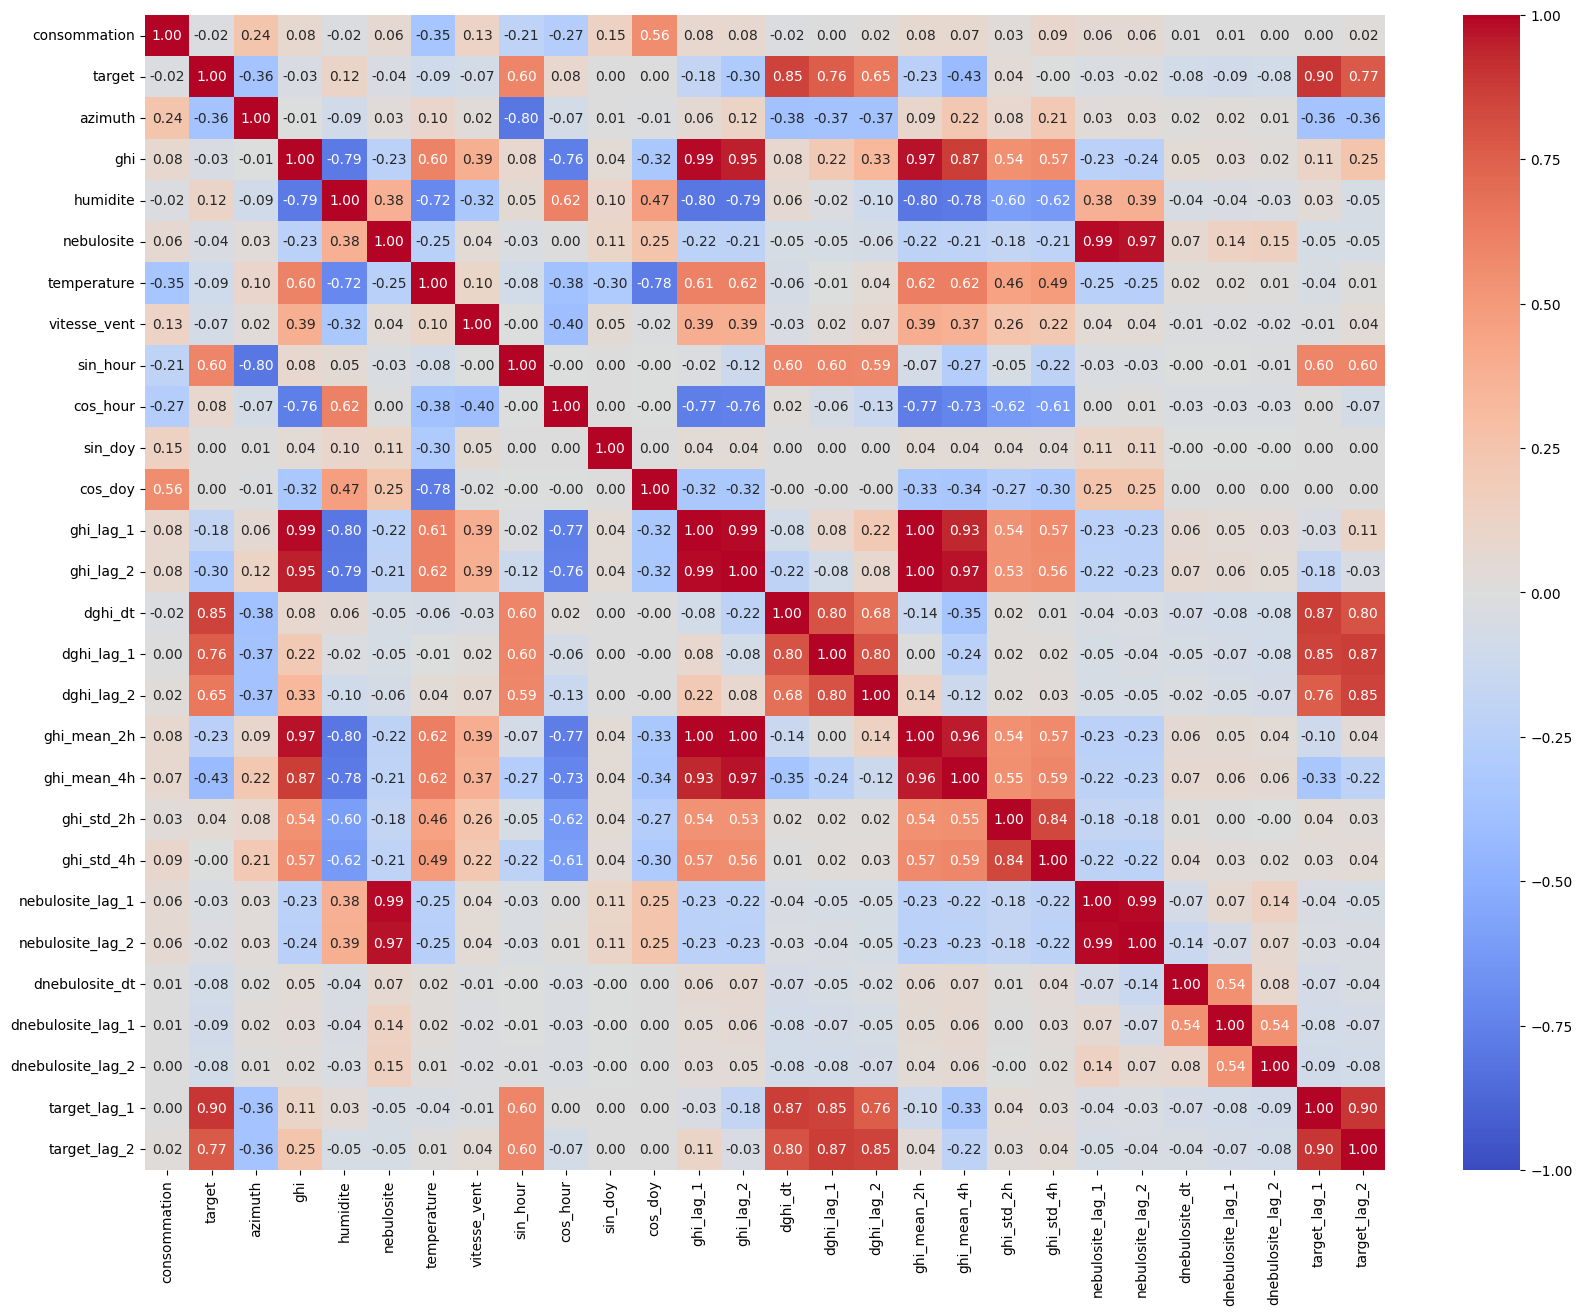

Variables avec au moins une corrélation supérieure à 80% : ['sin_hour', 'ghi_lag_1', 'ghi_lag_2', 'dghi_dt', 'ghi_mean_2h', 'ghi_mean_4h', 'ghi_std_4h', 'nebulosite_lag_1', 'nebulosite_lag_2', 'target_lag_1', 'target_lag_2']


In [51]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1.0, vmax=1.0)
plt.show()

print("Variables avec au moins une corrélation supérieure à 80% :", get_correlated_columns(df, threshold=0.8))
